# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**: Jinrong Yang  

**ID**: jy2256

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [285]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Downloads/Cornell/BEE 5750/hw2-jinry`


In [286]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

In [287]:
using Pkg
Pkg.add("GraphRecipes")

   Resolving package versions...
  No Changes to `~/Downloads/Cornell/BEE 5750/hw2-jinry/Project.toml`
  No Changes to `~/Downloads/Cornell/BEE 5750/hw2-jinry/Manifest.toml`


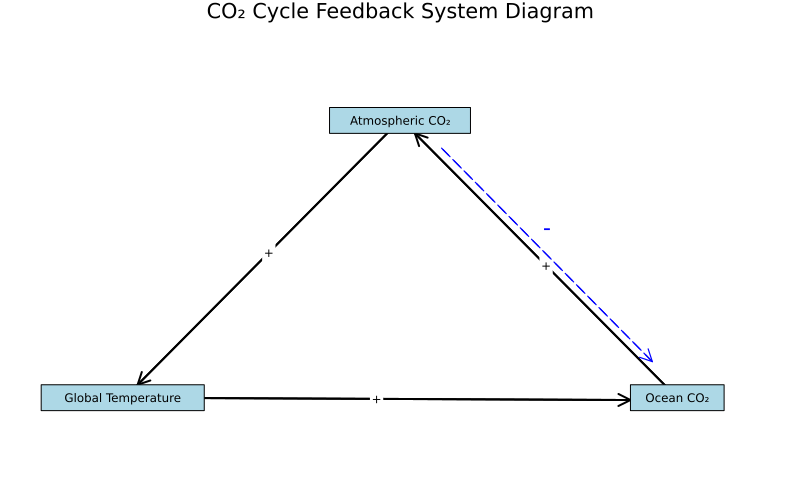

In [288]:
using GraphRecipes, Plots

A = [0 1 0;
     0 0 1; 
     1 0 0]  

names = ["Atmospheric CO₂", "Global Temperature", "Ocean CO₂"]

edge_labels = Dict((1, 2) => "+", (2, 3) => "+", (3, 1) => "+")

shapes = [:rect, :rect, :rect]
xpos = [0, -1, 1]
ypos = [1, 0, 0]

p = graphplot(A, names=names, edgelabel=edge_labels, markersize=0.07, 
              markershapes=shapes, markercolor=:lightblue, x=xpos, y=ypos,
              arrow=:true, curves=false, linewidth=2, fontsize=8,
              title="CO₂ Cycle Feedback System Diagram")


x_start, y_start = xpos[1] + 0.15, ypos[1] - 0.1  
x_end, y_end = xpos[3] - 0.09, ypos[3] + 0.13   


plot!([x_start, x_end], [y_start, y_end], 
      line=:dash, linewidth=1.2, color=:blue, arrow=true, arrowhead=:triangle, size=(800, 500))


annotate!((x_start + x_end)/2, (y_start + y_end)/2 + 0.1, 
          text("-", 15, :blue, :center))

display(p)

I drew it base on the understanding that when the concentration of atmospheric CO₂ rises, it acts as a greenhouse gas, which leads to an increase in the global mean temperature. This rise in temperature then negatively affects the ocean's ability to store CO₂, mainly by reducing the solubility of CO₂ in seawater. Consequently, the ocean releases more CO₂ back into the atmosphere, reinforcing this cycle. The dashed arrow is drawn because of Henry's Law. When air has more CO₂ than the ocean, the gas naturally dissolves into the seawater. This helps to lower the CO₂ in the air. 

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
<img src="attachment:figures/river_diagram.png"
alt="Schematic of the river system in Problem 2" />
<figcaption aria-hidden="true">Schematic of the river system in Problem
2</figcaption>
</figure>

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?

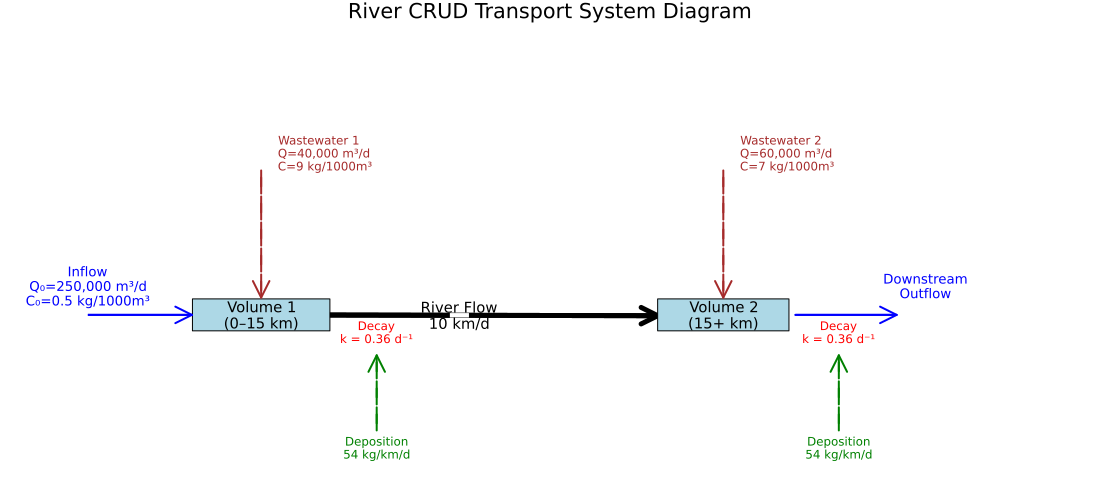

In [289]:
using GraphRecipes, Plots

A = [0 1;
     0 0]  

names = ["Volume 1\n(0–15 km)", 
         "Volume 2\n(15+ km)"]


edge_labels = Dict((1, 2) => "River Flow\n10 km/d")

shapes = [:rect, :rect]
xpos = [0, 8]  
ypos = [0, 0]

p = graphplot(A, 
              names=names, 
              edgelabel=edge_labels,
              markersize=0.3, 
              markershapes=shapes, 
              markercolor=:lightblue, 
              x=xpos, y=ypos,
              arrow=true, curves=false, linewidth=5, fontsize=10,
              title="River CRUD Transport System Diagram",
              xlim=(-3, 13), ylim=(-3, 5), 
              size=(1100, 500))


plot!([-5.25, -1.2], [0, 0], line=:solid, linewidth=2, color=:blue, arrow=true, arrowhead=:triangle)
annotate!(-3, 0.5, text("Inflow\nQ₀=250,000 m³/d\nC₀=0.5 kg/1000m³", 9, :blue, :center))

plot!([9.25, 11], [0, 0], line=:solid, linewidth=2, color=:blue, arrow=true, arrowhead=:triangle)
annotate!(11.5, 0.5, text("Downstream\nOutflow", 9, :blue, :center))

plot!([0, 0], [2.5, 0.3], line=:dash, linewidth=2, color=:brown, arrow=true, arrowhead=:triangle)
annotate!(0.3, 2.8, text("Wastewater 1\nQ=40,000 m³/d\nC=9 kg/1000m³", 8, :brown, :left))

plot!([8, 8], [2.5, 0.3], line=:dash, linewidth=2, color=:brown, arrow=true, arrowhead=:triangle)
annotate!(8.3, 2.8, text("Wastewater 2\nQ=60,000 m³/d\nC=7 kg/1000m³", 8, :brown, :left))

plot!([2, 2], [-2, -0.7], line=:dash, linewidth=2, color=:green, arrow=true, arrowhead=:triangle)
annotate!(2, -2.3, text("Deposition\n54 kg/km/d", 8, :green, :center))

plot!([10, 10], [-2, -0.7], line=:dash, linewidth=2, color=:green, arrow=true, arrowhead=:triangle)
annotate!(10, -2.3, text("Deposition\n54 kg/km/d", 8, :green, :center))

annotate!(2, -0.3, text("Decay\nk = 0.36 d⁻¹", 8, :red, :center))
annotate!(10, -0.3, text("Decay\nk = 0.36 d⁻¹", 8, :red, :center))

display(p)


I decided to include two boxes for control volumes in this system diagram. I divided it into two boxes because the variables to be considered for each box are different. For the first box, it only needs to consider the concentration changes caused by the inflow of water and wastewater 1. For box2, it needs to take into account the water from box1, the concentration changes caused by natural atmospheric deposition, and the concentration changes caused by wastewater2.

#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.

> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

Left-hand side (C dT/dt): The rate at which the Earth's climate system stores heat. C is the heat capacity, and dT/dt is the rate of temperature change.
Right-hand side: The net energy flow into the system. we solve the equation for the derivative dT/dt, which represents the instantaneous rate of temperature change.

To prepare for discretization, I realize i need to solve the equation for the derivative dT/dt, which represents the instantaneous rate of temperature change:

$$
\frac{dT}{dt} = \frac{1}{C} \left[ \frac{(1 - \alpha)S}{4} - \left( A - B T \right) \right]
$$


Since, we cannot directly equate a rate per year (°C/year) to a rate per second (J/(s·m²)), I multiply the right-hand side by the number of seconds in a year to convert the energy flow from a power (Joules/second) to an annual energy (Joules/year).

$$
\frac{dT}{dt} = \frac{1}{C} \left[ \frac{(1 - \alpha(T))S}{4} - \left( A - B T \right) \right]
\quad k_{year}
$$


We can now apply the Forward Euler Discretization and apply the Forward Euler Discretization. And we already know that delta t is the discrete time step (1 year, as given in the problem). We can find the equation to be：


$$
T_{n+1} = T_n + \frac{k^{year}}{C} 
\left[ \frac{(1 - \alpha(T_n))S}{4} - \left( A - B T_n \right) \right]
$$



#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

In [314]:
using Plots

# 物理常数
C = 51.0  # J/(m²·°C)
A = 221.2 # W/m²
B = -1.3  # W/(m²·°C)
α_i = 0.5 # ice albedo
α_0 = 0.3 # ocean albedo
S_present = 1368.0 # present solar constant
S_neoproterozoic = 1272.0 # Neoproterozoic solar constant

# 单位转换
seconds_per_year = 365.25 * 24 * 3600

# 反照率函数
function albedo(T)
    if T ≤ -10.0
        return α_i
    elseif T ≥ 10.0
        return α_0
    else
        return α_i + (α_0 - α_i) * ((T + 10.0) / 20.0)
    end
end

# 温度变化率函数
function dT_dt(T, S)
    incoming = (1.0 - albedo(T)) * S / 4.0
    outgoing = A - B * T
    net_energy = incoming - outgoing
    return (seconds_per_year / C) * net_energy
end

# 模拟函数
function simulate(T0, S, years, Δt=1.0)
    T_values = Float64[T0]
    T_current = T0
    
    for t in 1:years
        T_next = T_current + dT_dt(T_current, S) * Δt
        push!(T_values, T_next)
        T_current = T_next
    end
    
    return T_values
end

# Problem 3.2 模拟
simulation_years = 200
initial_temperatures = -60:10:30

# 创建图表并自定义刻度
plt = plot(xlabel="Time (years)", ylabel="Temperature (°C)", 
           title="Climate Model Trajectories (Neoproterozoic S=$(S_neoproterozoic))", 
           legend=:bottomright,
           size=(800, 600),
           xlims=(0, simulation_years),
           xticks=0:40:simulation_years,  # 自定义x轴刻度
           yticks=-60:20:40)              # 自定义y轴刻度

for T0 in initial_temperatures
    trajectory = simulate(T0, S_neoproterozoic, simulation_years)
    plot!(plt, 0:simulation_years, trajectory, label="T₀ = $T0", linewidth=2)
end

display(plt)

#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

## References

List any external references consulted, including classmates.